<Figure size 4500x3600 with 0 Axes>

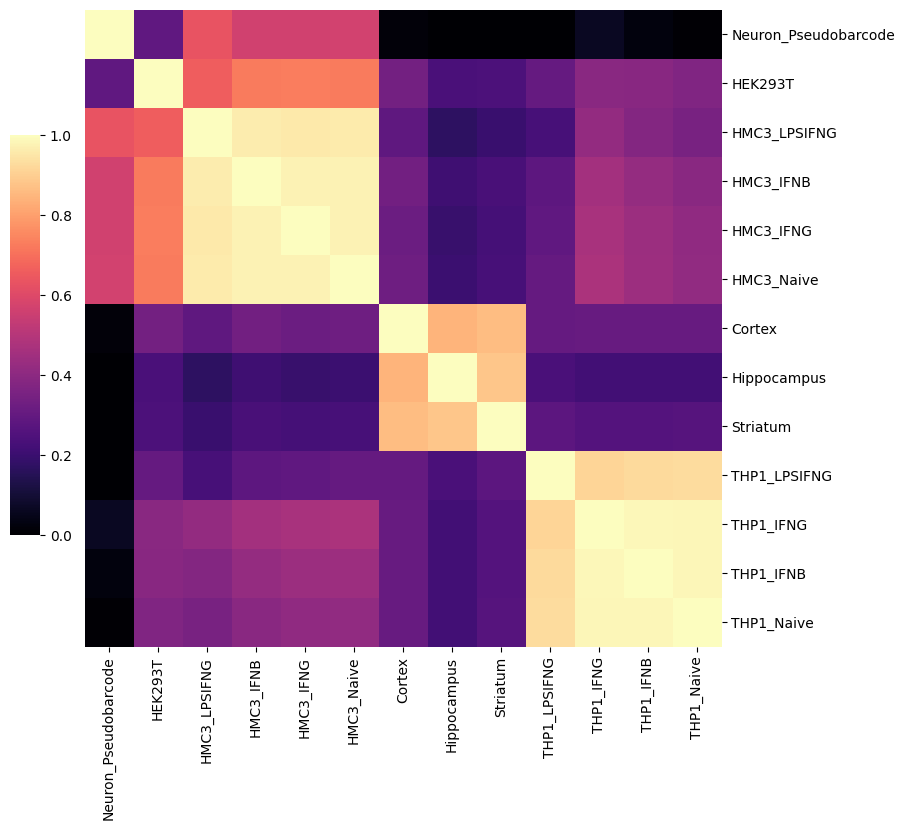

In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
# Collect all mad.score series along with their indices
all_scores = []
names = []
base_dir = "enhancer_activities/MAD_OneTail_NoControl"
for f in os.listdir(base_dir):
    if f.endswith('.csv') and not f.startswith('._'):
        folder_path = os.path.join(base_dir, f)

        df_tmp = pd.read_csv(folder_path, index_col=0)
        mad = df_tmp['mad.score']
        names.append(f[13:-4])
        all_scores.append(mad)

# Find common index (intersection of all indices)
common_index = all_scores[0].index
for score in all_scores[1:]:
    common_index = common_index.intersection(score.index)

# Reindex all mad.score series to the common index
final_scores = []
for score in all_scores:
    reindexed_score = score.reindex(common_index)
    final_scores.append(reindexed_score)

# Create DataFrame from the reindexed scores
final_df = pd.DataFrame(final_scores, index=names).T

# Visualize correlation matrix using seaborn
import seaborn as sns
plt.figure(figsize=(15, 12), dpi=300)
cg = sns.clustermap(final_df.drop(["Brain","THP1Macrophage","HMC3Cell","THP1Monocyte"],axis=1).corr('spearman'),vmin=0,vmax=1, annot=False, fmt=".2f", cmap='magma',
               )
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
cg.cax.set_position([0.1, 0.3, 0.03, 0.4])  
#plt.savefig('mad_correlation_by_celltype_Heatmap.pdf', format='pdf')

In [3]:
folder_path


'enhancer_activities/MAD_OneTail_NoControl/._20260625_MAD_Neuron_Pseudobarcode.csv'

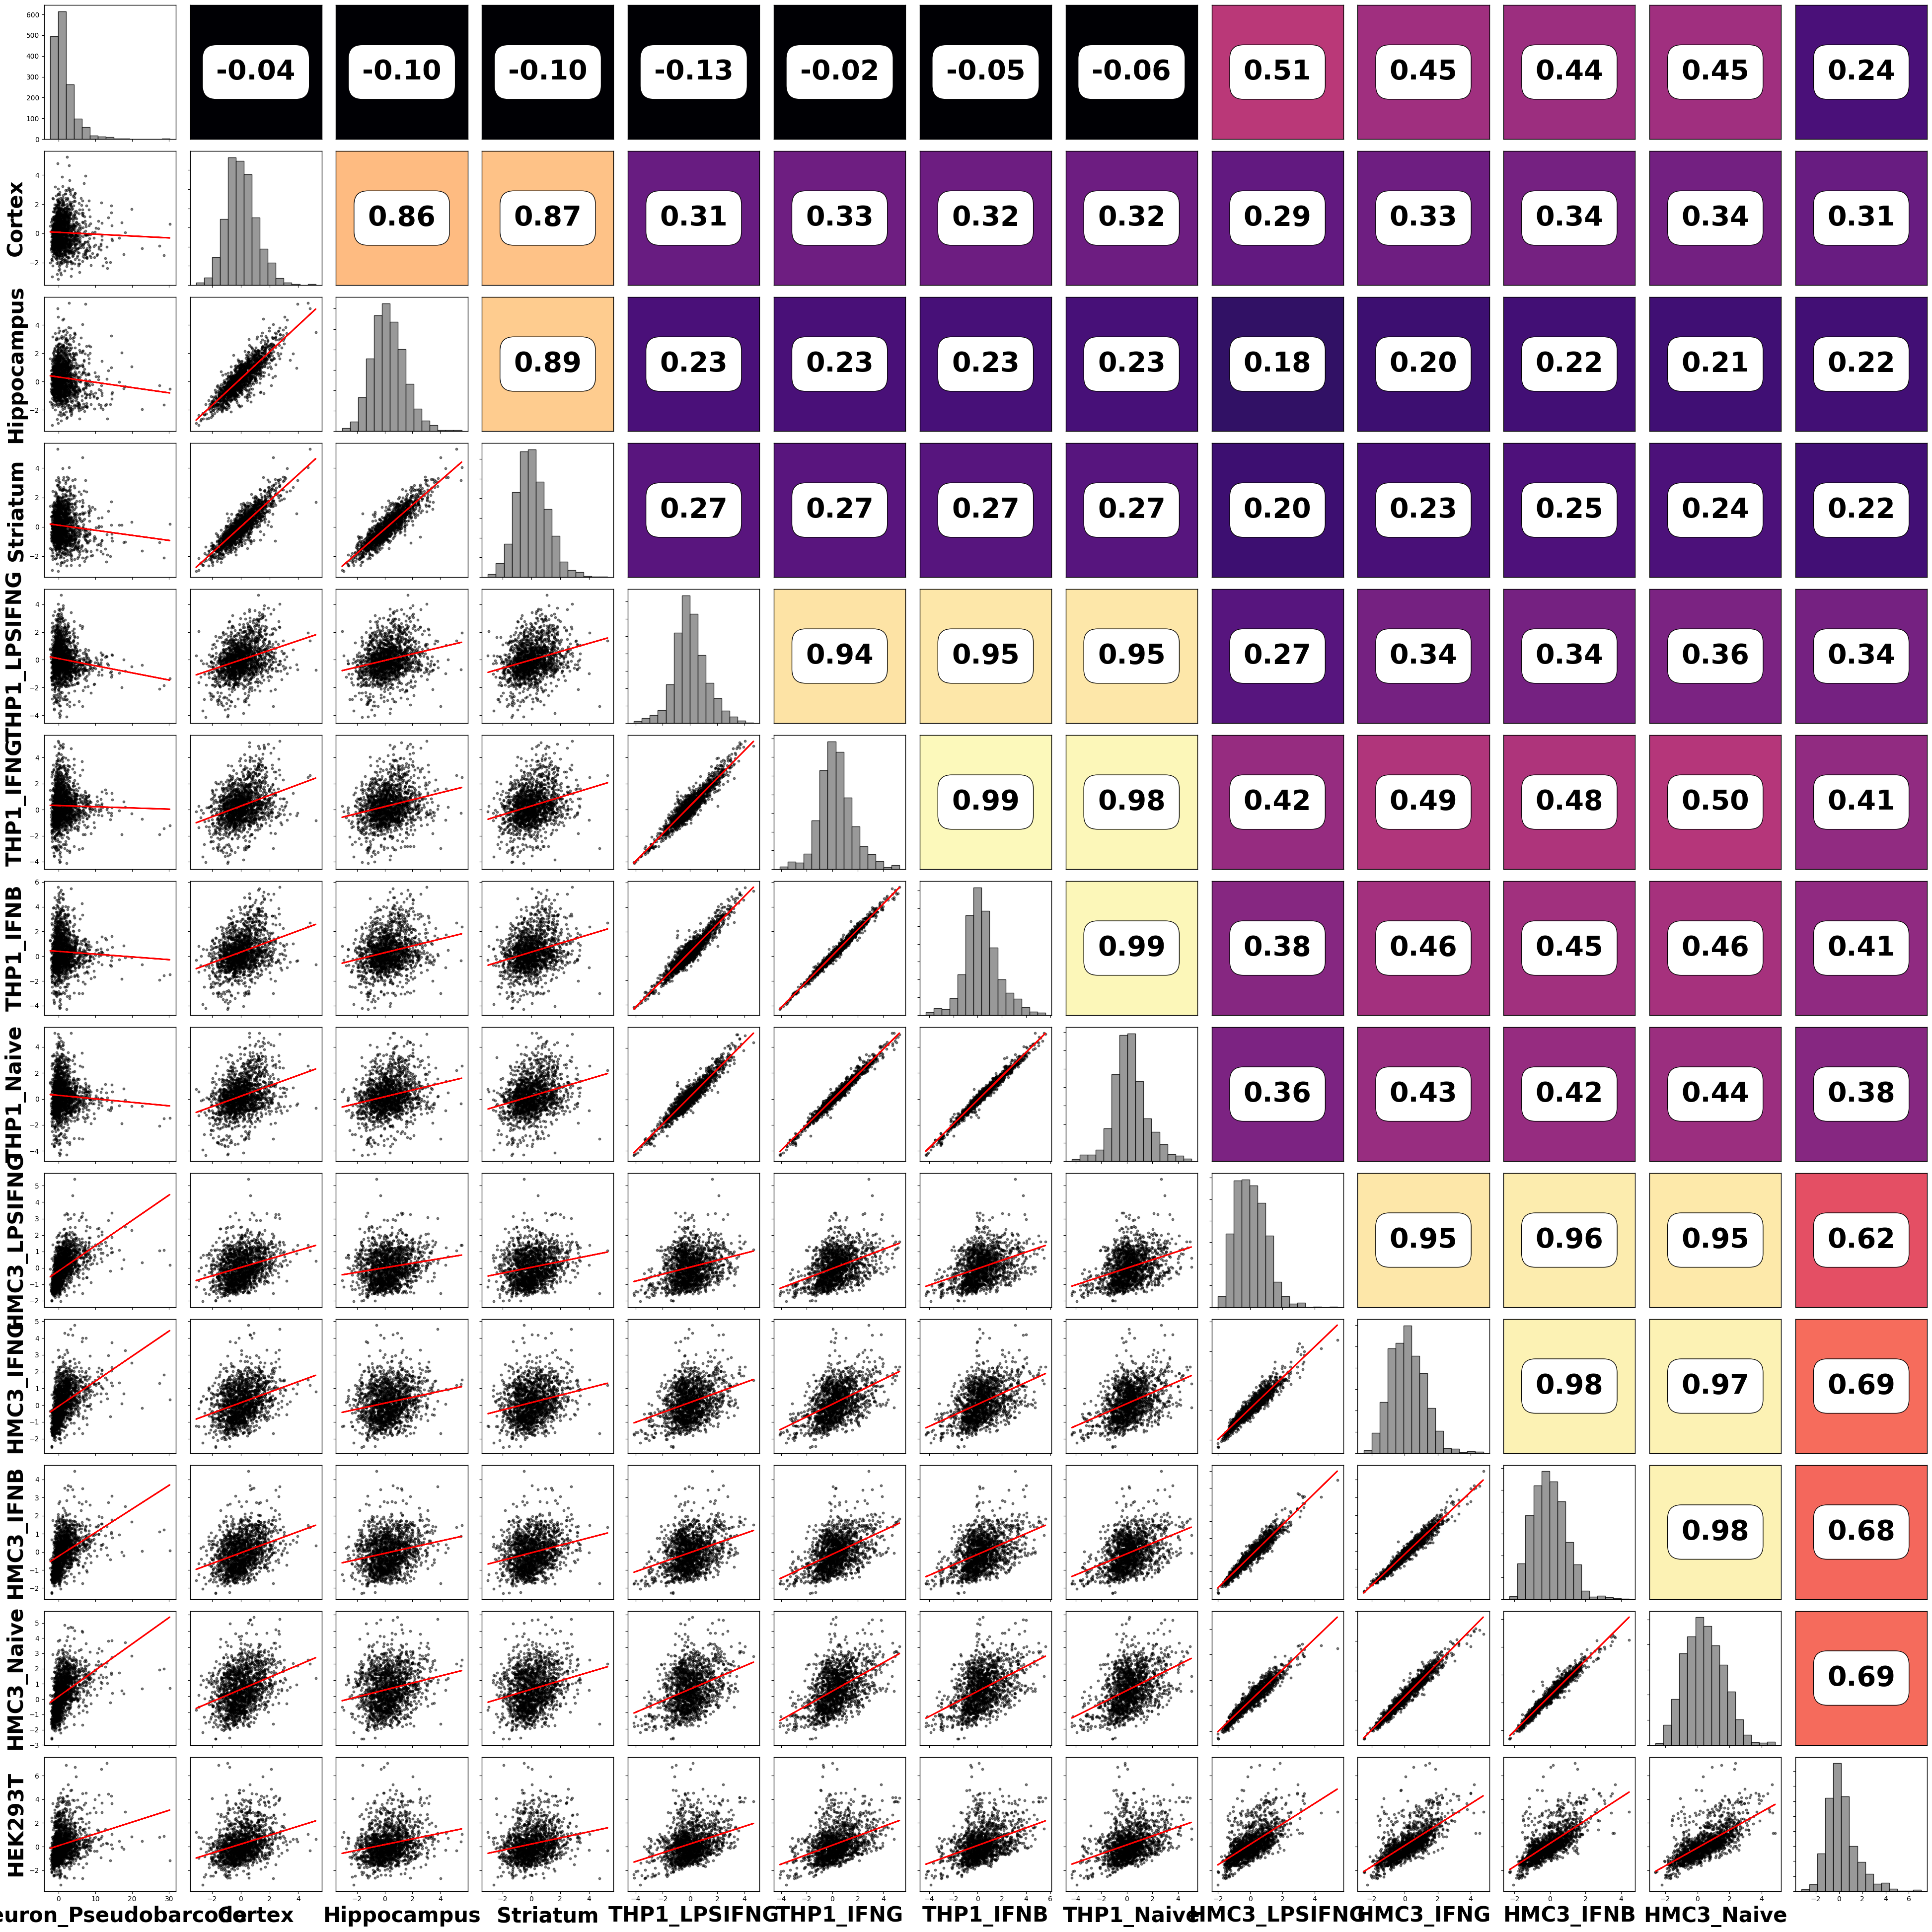

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --------------------------------------------------
# Assume 'final_df' is created as in your original code:
# final_df = pd.DataFrame(final_scores, index=names).T
# and you want to exclude certain columns:
df = final_df.drop(["Brain", "THP1Macrophage", "HMC3Cell", "THP1Monocyte"], axis=1)
df=df[['Neuron_Pseudobarcode','Cortex', 'Hippocampus','Striatum', 'THP1_LPSIFNG','THP1_IFNG','THP1_IFNB', 'THP1_Naive','HMC3_LPSIFNG','HMC3_IFNG', 'HMC3_IFNB',   'HMC3_Naive','HEK293T', ]]
# Number of variables (columns)
n = df.shape[1]
cols = df.columns

# Create figure and axes
fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n), dpi=100)

# Use "magma" colormap, matching your original code’s vmin=0, vmax=1
cmap = plt.get_cmap("magma")
norm = mcolors.Normalize(vmin=0, vmax=1)

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        # Draw a black border around each cell
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

        # Diagonal: histogram
        if i == j:
            data_hist = df.iloc[:, i]
            ax.hist(data_hist, bins=15, color='gray', edgecolor='black', alpha=0.8)
            # Bigger, bolder title inside the subplot
            #ax.set_title(cols[i], fontsize=25, fontweight='bold')

            # Show labels ONLY if it's on the leftmost column (j=0) or the bottom row (i=n-1)
            if i != n - 1:
                ax.set_xticklabels([])
            if j != 0:
                ax.set_yticklabels([])

        # Lower triangle: scatter + regression line
        elif i > j:
            x = df.iloc[:, j]
            y = df.iloc[:, i]

            # Scatter in black
            ax.scatter(x, y, s=10, c='black', alpha=0.5)

            # Fit a linear regression line: y = m*x + b
            m, b = np.polyfit(x, y, 1)
            ax.plot(x, m*x + b, color='red', linewidth=2)

            # Show x-axis label only if we are on the bottom row (i == n-1)
            if i == n - 1:
                ax.set_xlabel(cols[j], fontsize=30,fontweight='bold')
            else:
                ax.set_xticklabels([])

            # Show y-axis label only if we are on the leftmost column (j == 0)
            if j == 0:
                ax.set_ylabel(cols[i], fontsize=30,fontweight='bold')
            else:
                ax.set_yticklabels([])

        # Upper triangle: colored background + correlation text
        else:
            # Compute Pearson correlation
            corr = df.iloc[:, i].corr(df.iloc[:, j], method='pearson')

            # Clamp correlation to [0, 1] to match the original vmin/vmax
            corr_clamped = np.clip(corr, 0, 1)
            # Set face color according to the correlation (0 to 1)
            ax.set_facecolor(cmap(norm(corr_clamped)))

            # Show correlation text, 2.5 times bigger (e.g., ~30 if originally ~12)
            ax.text(
                0.5, 0.5, f"{corr:.2f}",
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=40, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
            )

            # Turn off ticks for upper triangle
            ax.set_xticks([])
            ax.set_yticks([])

# Adjust layout so everything fits nicely
plt.tight_layout()

# Save figure (optional)
#plt.savefig("styled_scatter_matrix_magma.pdf", dpi=300, bbox_inches="tight")
#plt.savefig("styled_scatter_matrix_magma.png", dpi=300, bbox_inches="tight")
plt.show()


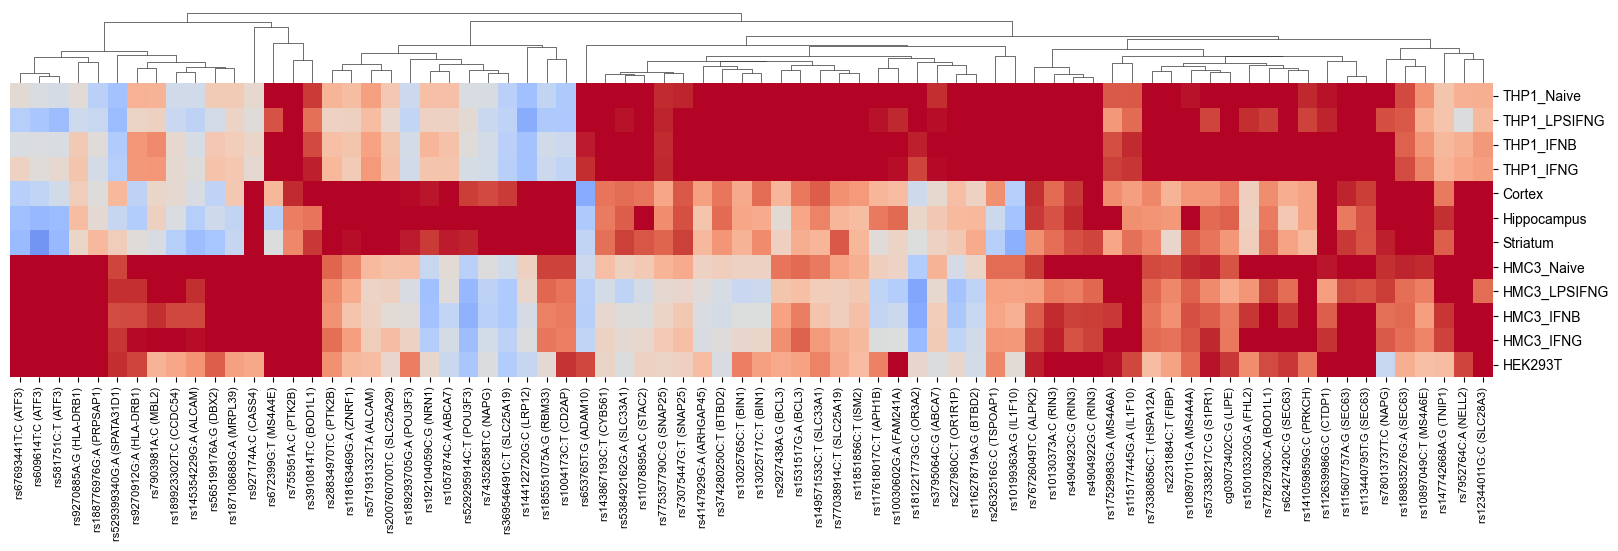

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

# --------------------------------------------------
# Make text editable in Illustrator
# --------------------------------------------------
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "Arial"

# --------------------------------------------------
# Load and prepare data
# --------------------------------------------------
df_haploreg = pd.read_csv(
    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv",
    index_col=0
)
df_index = pd.read_csv(
    "indexing/ALT_REF_LookUpTable_filtered_amended_alleleOnly_20240605.csv"
)

df_alt = final_df.loc[df_index["0"]]
df_ref = final_df.loc[df_index["1"]]
df_ref.index = df_alt.index

df_mad_average_refalt = (df_alt + df_ref) / 2
df_mad_average_refalt_normalized = df_mad_average_refalt / df_mad_average_refalt.std()

immune_columns = ["THP1_IFNB", "THP1_IFNG", "THP1_LPSIFNG", "THP1_Naive"]
brain_columns = ["Cortex", "Hippocampus", "Striatum"]
hmc3_columns = ["HMC3_IFNB", "HMC3_IFNG", "HMC3_LPSIFNG", "HMC3_Naive"]

df_mad_average_refalt_normalized_immune = df_mad_average_refalt_normalized[immune_columns]
df_mad_average_refalt_normalized_brain = df_mad_average_refalt_normalized[brain_columns]
df_mad_average_refalt_normalized_hmc3 = df_mad_average_refalt_normalized[hmc3_columns]

immune_all = df_mad_average_refalt_normalized_immune[
    (df_mad_average_refalt_normalized_immune >= 1.65).all(axis=1)
]
hmc3_all = df_mad_average_refalt_normalized_hmc3[
    (df_mad_average_refalt_normalized_hmc3 >= 1.65).all(axis=1)
]
brain_all = df_mad_average_refalt_normalized_brain[
    (df_mad_average_refalt_normalized_brain >= 1.65).all(axis=1)
]

immune_brain_index = (
    immune_all.index.tolist()
    + brain_all.index.tolist()
    + hmc3_all.index.tolist()
)

haploreg_immune_brain_unique = df_haploreg.loc[immune_brain_index].drop_duplicates("rsid")

# --------------------------------------------------
# Fixed y-axis order
# --------------------------------------------------
plot_order = [
    "THP1_Naive",
    "THP1_LPSIFNG",
    "THP1_IFNB",
    "THP1_IFNG",
    "Cortex",
    "Hippocampus",
    "Striatum",
    "HMC3_Naive",
    "HMC3_LPSIFNG",
    "HMC3_IFNB",
    "HMC3_IFNG",
    "HEK293T",
]

df_plot = df_mad_average_refalt_normalized[plot_order].loc[
    haploreg_immune_brain_unique.index.unique()
].copy()

df_plot.index = haploreg_immune_brain_unique.loc[
    df_plot.index, "rsid_gene_tss"
].values

# --------------------------------------------------
# Clustermap:
# keep x-direction clustering, fix y-direction order
# --------------------------------------------------
g = sns.clustermap(
    df_plot.T,
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
    center=0,
    figsize=(20, 6),
    row_cluster=False,   # y-axis fixed order
    col_cluster=True,    # x-axis clustered
    cbar_pos=None,       # 不画 colorbar
    xticklabels=True,
    yticklabels=True,
    linewidths=0,
)

# 隐藏左侧 dendrogram
g.ax_row_dendrogram.set_visible(False)

# 如果你也不想显示顶部 clustering 线，但保留 clustered 后的 x 顺序：
# g.ax_col_dendrogram.set_visible(False)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=90,
    fontsize=8
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    fontsize=10
)

g.savefig("haploreg_heatmap_main_only.pdf", dpi=300)
#g.savefig("haploreg_heatmap_main_only.svg", dpi=300)

plt.show()

In [8]:
import sklearn.preprocessing
import numpy as np

# vocabularies:
DNA = ["A", "C", "G", "T"]
RNA = ["A", "C", "G", "U"]
AMINO_ACIDS = ["A", "R", "N", "D", "B", "C", "E", "Q", "Z", "G", "H",
               "I", "L", "K", "M", "F", "P", "S", "T", "W", "Y", "V"]
CODONS = ["AAA", "AAC", "AAG", "AAT", "ACA", "ACC", "ACG", "ACT", "AGA",
          "AGC", "AGG", "AGT", "ATA", "ATC", "ATG", "ATT", "CAA", "CAC",
          "CAG", "CAT", "CCA", "CCC", "CCG", "CCT", "CGA", "CGC", "CGG",
          "CGT", "CTA", "CTC", "CTG", "CTT", "GAA", "GAC", "GAG", "GAT",
          "GCA", "GCC", "GCG", "GCT", "GGA", "GGC", "GGG", "GGT", "GTA",
          "GTC", "GTG", "GTT", "TAC", "TAT", "TCA", "TCC", "TCG", "TCT",
          "TGC", "TGG", "TGT", "TTA", "TTC", "TTG", "TTT"]
STOP_CODONS = ["TAG", "TAA", "TGA"]


def _get_vocab_dict(vocab):
    return {l: i for i, l in enumerate(vocab)}


def _get_index_dict(vocab):
    return {i: l for i, l in enumerate(vocab)}


def one_hot2token(arr):
    return arr.argmax(axis=2)


# TODO - take into account the neutral vocab
def one_hot2string(arr, vocab):
    """Convert a one-hot encoded array back to string
    """
    tokens = one_hot2token(arr)
    indexToLetter = _get_index_dict(vocab)

    return [''.join([indexToLetter[x] for x in row]) for row in tokens]


def tokenize(seq, vocab, neutral_vocab=[]):
    """Convert sequence to integers

    # Arguments
       seq: Sequence to encode
       vocab: Vocabulary to use
       neutral_vocab: Neutral vocabulary -> assign those values to -1

    # Returns
       List of length `len(seq)` with integers from `-1` to `len(vocab) - 1`
    """
    # Req: all vocabs have the same length
    if isinstance(neutral_vocab, str):
        neutral_vocab = [neutral_vocab]

    nchar = len(vocab[0])
    for l in vocab + neutral_vocab:
        assert len(l) == nchar
    assert len(seq) % nchar == 0  # since we are using striding

    vocab_dict = _get_vocab_dict(vocab)
    for l in neutral_vocab:
        vocab_dict[l] = -1

    # current performance bottleneck
    return [vocab_dict[seq[(i * nchar):((i + 1) * nchar)]] for i in range(len(seq) // nchar)]


# 512 ms vs 121 -> 4x slower than custom token2one_hot
# def token2one_hot(tvec, vocab_size):
#     """
#     Note: everything out of the vucabulary is transformed into `np.zeros(vocab_size)`
#     """
#     # This costs the most - memory allocation?
#     lb = sklearn.preprocessing.LabelBinarizer()
#     lb.fit(range(vocab_size))
#     return lb.transform(tvec)
#     # alternatively:
#     # return sklearn.preprocessing.label_binarize(tvec, list(range(vocab_size)))


def token2one_hot(tvec, vocab_size):
    """
    Note: everything out of the vucabulary is transformed into `np.zeros(vocab_size)`
    """
    arr = np.zeros((len(tvec), vocab_size))

    tvec_range = np.arange(len(tvec))
    tvec = np.asarray(tvec)
    arr[tvec_range[tvec >= 0], tvec[tvec >= 0]] = 1
    return arr


def encodeSequence(seq_vec, vocab, neutral_vocab, maxlen=None,
                   seq_align="start", pad_value="N", encode_type="one_hot"):
    """Convert a list of genetic sequences into one-hot-encoded array.

    # Arguments
       seq_vec: list of strings (genetic sequences)
       vocab: list of chars: List of "words" to use as the vocabulary. Can be strings of length>0,
            but all need to have the same length. For DNA, this is: ["A", "C", "G", "T"].
       neutral_vocab: list of chars: Values used to pad the sequence or represent unknown-values. For DNA, this is: ["N"].
       maxlen: int or None,
            Should we trim (subset) the resulting sequence. If None don't trim.
            Note that trims wrt the align parameter.
            It should be smaller than the longest sequence.
       seq_align: character; 'end' or 'start'
            To which end should we align sequences?
       encode_type: "one_hot" or "token". "token" represents each vocab element as a positive integer from 1 to len(vocab) + 1.
                  neutral_vocab is represented with 0.

    # Returns
        Array with shape for encode_type:

            - "one_hot": `(len(seq_vec), maxlen, len(vocab))`
            - "token": `(len(seq_vec), maxlen)`

        If `maxlen=None`, it gets the value of the longest sequence length from `seq_vec`.
    """
    if isinstance(neutral_vocab, str):
        neutral_vocab = [neutral_vocab]
    if isinstance(seq_vec, str):
        raise ValueError("seq_vec should be an iterable returning " +
                         "strings not a string itself")
    assert len(vocab[0]) == len(pad_value)
    assert pad_value in neutral_vocab

    assert encode_type in ["one_hot", "token"]

    seq_vec = pad_sequences(seq_vec, maxlen=maxlen,
                            align=seq_align, value=pad_value)

    if encode_type == "one_hot":
        arr_list = [token2one_hot(tokenize(seq, vocab, neutral_vocab), len(vocab))
                    for i, seq in enumerate(seq_vec)]
    elif encode_type == "token":
        arr_list = [1 + np.array(tokenize(seq, vocab, neutral_vocab)) for seq in seq_vec]
        # we add 1 to be compatible with keras: https://keras.io/layers/embeddings/
        # indexes > 0, 0 = padding element

    return np.stack(arr_list)


def encodeDNA(seq_vec, maxlen=None, seq_align="start"):
    """Convert the DNA sequence into 1-hot-encoding numpy array

    # Arguments
        seq_vec: list of chars
            List of sequences that can have different lengths

        maxlen: int or None,
            Should we trim (subset) the resulting sequence. If None don't trim.
            Note that trims wrt the align parameter.
            It should be smaller than the longest sequence.

        seq_align: character; 'end' or 'start'
            To which end should we align sequences?

    # Returns
        3D numpy array of shape (len(seq_vec), trim_seq_len(or maximal sequence length if None), 4)

    # Example

        ```python
            >>> sequence_vec = ['CTTACTCAGA', 'TCTTTA']
            >>> X_seq = encodeDNA(sequence_vec, seq_align="end", maxlen=8)
            >>> X_seq.shape
            (2, 8, 4)

            >>> print(X_seq)
            [[[0 0 0 1]
              [1 0 0 0]
              [0 1 0 0]
              [0 0 0 1]
              [0 1 0 0]
              [1 0 0 0]
              [0 0 1 0]
              [1 0 0 0]]

             [[0 0 0 0]
              [0 0 0 0]
              [0 0 0 1]
              [0 1 0 0]
              [0 0 0 1]
              [0 0 0 1]
              [0 0 0 1]
              [1 0 0 0]]]
        ```
    """
    return encodeSequence(seq_vec,
                          vocab=DNA,
                          neutral_vocab="N",
                          maxlen=maxlen,
                          seq_align=seq_align,
                          pad_value="N",
                          encode_type="one_hot")


def encodeRNA(seq_vec, maxlen=None, seq_align="start"):
    """Convert the RNA sequence into 1-hot-encoding numpy array as for encodeDNA
    """
    return encodeSequence(seq_vec,
                          vocab=RNA,
                          neutral_vocab="N",
                          maxlen=maxlen,
                          seq_align=seq_align,
                          pad_value="N",
                          encode_type="one_hot")


def encodeCodon(seq_vec, ignore_stop_codons=True, maxlen=None, seq_align="start", encode_type="one_hot"):
    """Convert the Codon sequence into 1-hot-encoding numpy array

    # Arguments
        seq_vec: List of strings/DNA sequences
        ignore_stop_codons: boolean; if True, STOP_CODONS are omitted from one-hot encoding.
        maxlen: Maximum sequence length. See `pad_sequences` for more detail
        seq_align: How to align the sequences of variable lengths. See `pad_sequences` for more detail
        encode_type: can be `"one_hot"` or `token` for token encoding of codons (incremental integer ).

    # Returns
        numpy.ndarray of shape `(len(seq_vec), maxlen / 3, 61 if ignore_stop_codons else 64)`
    """
    if ignore_stop_codons:
        vocab = CODONS
        neutral_vocab = STOP_CODONS + ["NNN"]
    else:
        vocab = CODONS + STOP_CODONS
        neutral_vocab = ["NNN"]

    # replace all U's with A's?
    seq_vec = [str(seq).replace("U", "T") for seq in seq_vec]

    return encodeSequence(seq_vec,
                          vocab=vocab,
                          neutral_vocab=neutral_vocab,
                          maxlen=maxlen,
                          seq_align=seq_align,
                          pad_value="NNN",
                          encode_type=encode_type)


def encodeAA(seq_vec, maxlen=None, seq_align="start", encode_type="one_hot"):
    """Convert the Amino-acid sequence into 1-hot-encoding numpy array

    # Arguments
        seq_vec: List of strings/amino-acid sequences
        maxlen: Maximum sequence length. See `pad_sequences` for more detail
        seq_align: How to align the sequences of variable lengths. See `pad_sequences` for more detail
        encode_type: can be `"one_hot"` or `token` for token encoding of codons (incremental integer ).

    # Returns
        numpy.ndarray of shape `(len(seq_vec), maxlen, 22)`
    """
    return encodeSequence(seq_vec,
                          vocab=AMINO_ACIDS,
                          neutral_vocab="_",
                          maxlen=maxlen,
                          seq_align=seq_align,
                          pad_value="_",
                          encode_type=encode_type)


def pad_sequences(sequence_vec, maxlen=None, align="end", value="N"):
    """Pad and/or trim a list of sequences to have common length. Procedure:

        1. Pad the sequence with N's or any other string or list element (`value`)
        2. Subset the sequence

    # Note
        See also: https://keras.io/preprocessing/sequence/
        Aplicable also for lists of characters

    # Arguments
        sequence_vec: list of chars or lists
            List of sequences that can have various lengths
        value: Neutral element to pad the sequence with. Can be `str` or `list`.
        maxlen: int or None; Final lenght of sequences.
             If None, maxlen is set to the longest sequence length.
        align: character; 'start', 'end' or 'center'
            To which end to align the sequences when triming/padding. See examples bellow.

    # Returns
        List of sequences of the same class as sequence_vec

    # Example

        ```python
            >>> sequence_vec = ['CTTACTCAGA', 'TCTTTA']
            >>> pad_sequences(sequence_vec, 10, align="start", value="N")
            ['CTTACTCAGA', 'TCTTTANNNN']
            >>> pad_sequences(sequence_vec, 10, align="end", value="N")
            ['CTTACTCAGA', 'NNNNTCTTTA']
            >>> pad_sequences(sequence_vec, 4, align="center", value="N")
            ['ACTC', 'CTTT']
        ```
    """

    # neutral element type checking
    assert isinstance(value, list) or isinstance(value, str)
    assert isinstance(value, type(sequence_vec[0]))
    assert not isinstance(sequence_vec, str)
    assert isinstance(sequence_vec[0], list) or isinstance(sequence_vec[0], str)

    max_seq_len = max([len(seq) for seq in sequence_vec])

    if maxlen is None:
        maxlen = max_seq_len
    else:
        maxlen = int(maxlen)

    if max_seq_len < maxlen:
        import warnings
        warnings.warn("Maximum sequence length (%s) is less than maxlen (%s)" % (max_seq_len, maxlen))
        max_seq_len = maxlen

    # check the case when len > 1
    for seq in sequence_vec:
        if not len(seq) % len(value) == 0:
            raise ValueError("All sequences need to be dividable by len(value)")
    if not maxlen % len(value) == 0:
        raise ValueError("maxlen needs to be dividable by len(value)")

    # pad and subset
    def pad(seq, max_seq_len, value="N", align="end"):
        seq_len = len(seq)
        assert max_seq_len >= seq_len
        if align == "end":
            n_left = max_seq_len - seq_len
            n_right = 0
        elif align == "start":
            n_right = max_seq_len - seq_len
            n_left = 0
        elif align == "center":
            n_left = (max_seq_len - seq_len) // 2 + (max_seq_len - seq_len) % 2
            n_right = (max_seq_len - seq_len) // 2
        else:
            raise ValueError("align can be of: end, start or center")

        # normalize for the length
        n_left = n_left // len(value)
        n_right = n_right // len(value)

        return value * n_left + seq + value * n_right

    def trim(seq, maxlen, align="end"):
        seq_len = len(seq)

        assert maxlen <= seq_len
        if align == "end":
            return seq[-maxlen:]
        elif align == "start":
            return seq[0:maxlen]
        elif align == "center":
            dl = seq_len - maxlen
            n_left = dl // 2 + dl % 2
            n_right = seq_len - dl // 2
            return seq[n_left:n_right]
        else:
            raise ValueError("align can be of: end, start or center")

    padded_sequence_vec = [pad(seq, max(max_seq_len, maxlen),
                               value=value, align=align) for seq in sequence_vec]
    padded_sequence_vec = [trim(seq, maxlen, align=align) for seq in padded_sequence_vec]

    return padded_sequence_vec

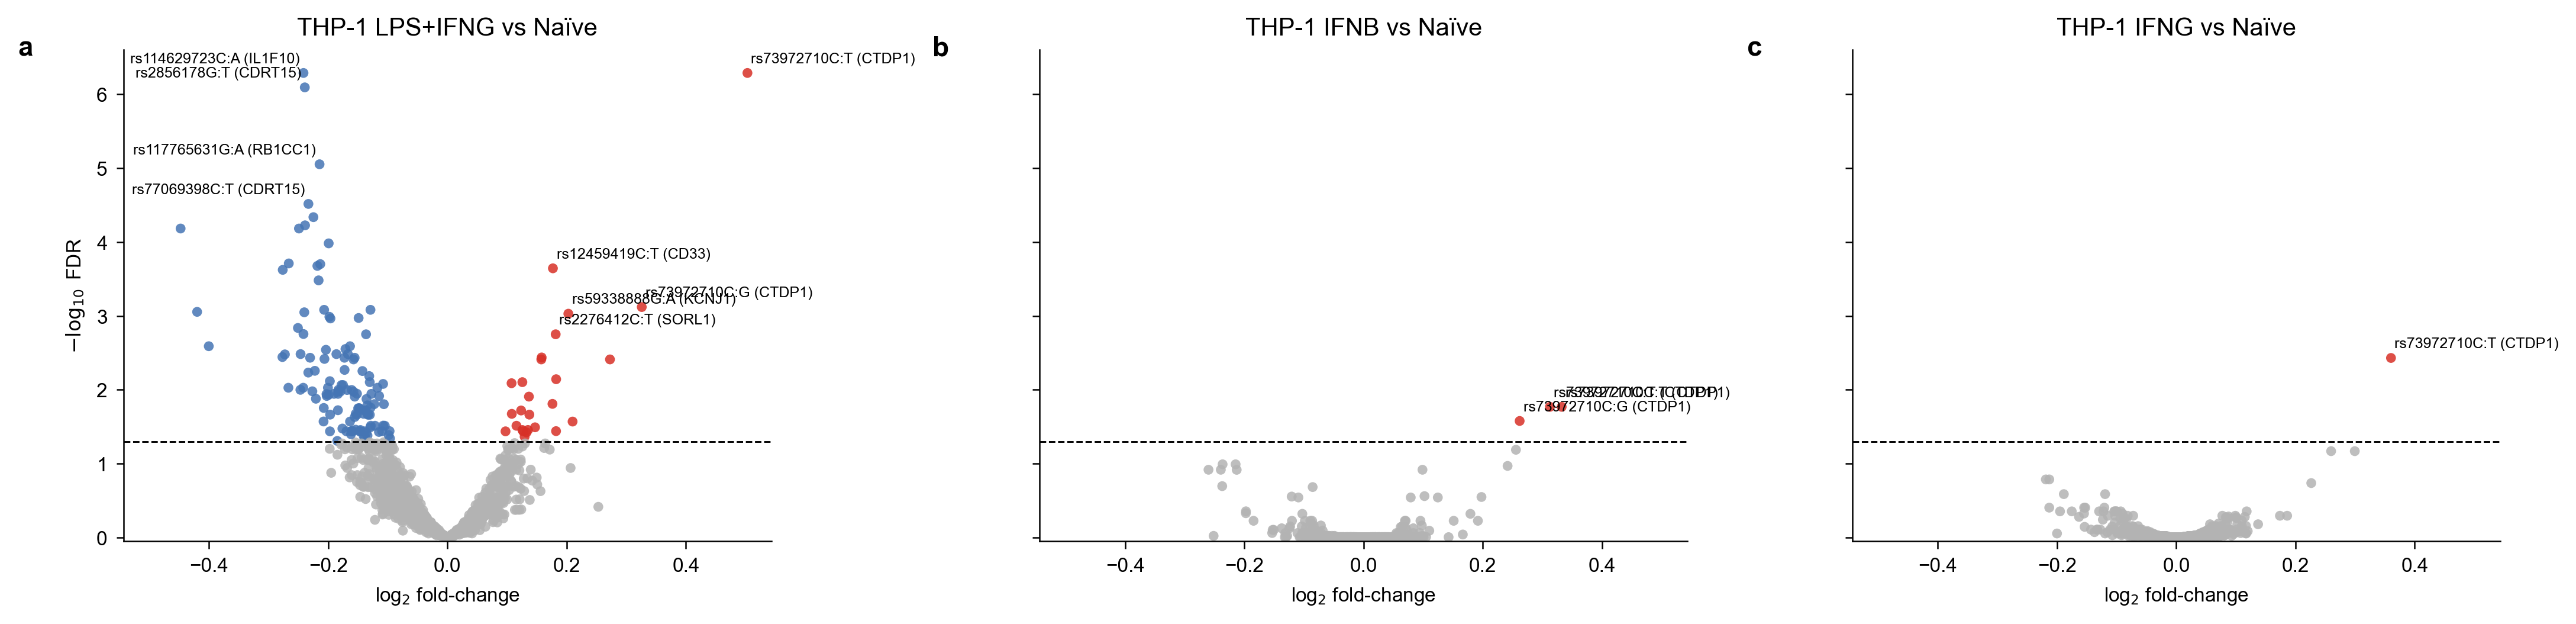

Saved to: E:\mpra3_lib_analysis\Fig_volcano_THP1_stimulation_balanced_labels.pdf


In [21]:
#!/usr/bin/env python3
# ------------------------------------------------------------------
# Volcano plots (THP-1: LPS+IFNG, IFNB, IFNG)
# - shared y-axis
# - balanced labeling: top up + top down significant hits
# - Arial font
# - Illustrator-editable PDF/SVG
# ------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import patheffects as pe
from pathlib import Path

# --------------------------- CONFIG ---------------------------------
SIG_THR = 0.05
N_UP = 5                      # max number of upregulated labels per panel
N_DOWN = 4                    # max number of downregulated labels per panel
PANEL_W = 4.8
PANEL_H = 3.4
OUTFILE_PDF = "Fig_volcano_THP1_stimulation_balanced_labels.pdf"
OUTFILE_SVG = "Fig_volcano_THP1_stimulation_balanced_labels.svg"

COL = {
    "ns":   "#B3B3B3",   # non-significant
    "up":   "#D73027",   # significant up-regulated
    "down": "#4575B4",   # significant down-regulated
}

# -------------------- Illustrator-editable text ---------------------
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "Arial"

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

# --------------------------- FUNCTIONS ------------------------------
def drop_rows_with_motifdisrupt(df: pd.DataFrame) -> pd.DataFrame:
    mask = df.iloc[:, 0].astype(str).str.contains("motifdisrupt", na=False)
    return df.loc[~mask].copy()

def load_diff_table(path: str) -> pd.DataFrame:
    return pd.read_csv(path, index_col=0)

def replace_indices_with_ref(df: pd.DataFrame, lut: pd.DataFrame) -> list[str]:
    """If an index starts with 'ref', map it to the ALT/REF ID in lookup table."""
    idx_map = pd.Series(lut.iloc[:, 0].values, index=lut.iloc[:, 1]).to_dict()
    return [idx_map.get(i, i) if str(i).startswith("ref") else i for i in df.index]

def choose_balanced_hits(tmp: pd.DataFrame, sig_thr: float, n_up: int, n_down: int) -> pd.DataFrame:
    """
    Select labels in a balanced way:
    - top n_up significant upregulated hits by smallest FDR
    - top n_down significant downregulated hits by smallest FDR
    """
    tmp_sig = tmp.loc[tmp["fdr"] <= sig_thr].copy()

    hits_up = (
        tmp_sig.loc[tmp_sig["logFC"] > 0]
        .sort_values(["fdr", "logFC"], ascending=[True, False])
        .head(n_up)
    )

    hits_down = (
        tmp_sig.loc[tmp_sig["logFC"] < 0]
        .sort_values(["fdr", "logFC"], ascending=[True, True])
        .head(n_down)
    )

    hits = pd.concat([hits_up, hits_down], axis=0).drop_duplicates()

    # Optional: within the selected set, order by y then abs(x) for cleaner annotation
    if not hits.empty:
        hits = hits.assign(abs_logFC=np.abs(hits["logFC"]))
        hits = hits.sort_values(["-log10FDR", "abs_logFC"], ascending=[False, False]).drop(columns="abs_logFC")

    return hits

# --------------------------- DATA LOAD ------------------------------
df_index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv")
df_index = drop_rows_with_motifdisrupt(df_index)

annot_path = (
    "indexing/"
    "SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_"
    "Bellenguez_TSS_genomicML_20250324.csv"
)
df_annot = pd.read_csv(annot_path, index_col=0)  # must contain rsid_gene_tss

# Explicit plotting order: LPS first, then beta, then gamma
diff_files = [
    (
        "THP-1 LPS+IFNG vs Naïve",
        "enhancer_activities_differential/20240626_comparative_THP1_LPSIFNGvsNaive_DifferentialEnhancer.csv",
    ),
    (
        "THP-1 IFNB vs Naïve",
        "enhancer_activities_differential/20240626_comparative_THP1_IFNBvsNaive_DifferentialEnhancer.csv",
    ),
    (
        "THP-1 IFNG vs Naïve",
        "enhancer_activities_differential/20240626_comparative_THP1_IFNGvsNaive_DifferentialEnhancer.csv",
    ),
]

comparisons = [(title, load_diff_table(path)) for title, path in diff_files]

# Attach rsid_gene_tss
for _, df in comparisons:
    resolved_idx = replace_indices_with_ref(df, df_index)
    df["rsid_gene_tss"] = df_annot.reindex(resolved_idx)["rsid_gene_tss"].values

# --------------------------- PREP -----------------------------------
max_abs = max(np.nanmax(np.abs(df["logFC"].values)) for _, df in comparisons)
max_y = 0

prepared = []
for title, df in comparisons:
    tmp = df.copy()
    tmp["-log10FDR"] = -np.log10(tmp["fdr"].clip(lower=1e-300))
    tmp["sig"] = "ns"
    tmp.loc[(tmp["fdr"] <= SIG_THR) & (tmp["logFC"] > 0), "sig"] = "up"
    tmp.loc[(tmp["fdr"] <= SIG_THR) & (tmp["logFC"] < 0), "sig"] = "down"

    max_y = max(max_y, tmp["-log10FDR"].max())
    prepared.append((title, tmp))

# --------------------------- PLOTTING -------------------------------
fig, axes = plt.subplots(
    ncols=3,
    sharey=True,
    figsize=(PANEL_W * 3, PANEL_H),
    constrained_layout=True
)

for ax, (title, tmp) in zip(axes, prepared):
    sns.scatterplot(
        data=tmp,
        x="logFC",
        y="-log10FDR",
        hue="sig",
        palette=COL,
        hue_order=["ns", "up", "down"],
        edgecolor="none",
        s=16,
        alpha=0.85,
        legend=False,
        ax=ax,
    )

    # FDR threshold
    ax.axhline(-np.log10(SIG_THR), ls="--", lw=0.7, color="black")

    # limits & style
    ax.set_xlim(-max_abs * 1.08, max_abs * 1.08)
    ax.set_ylim(-0.05, max_y * 1.05)
    ax.set_xlabel(r"log$_2$ fold-change", labelpad=4)
    ax.set_title(title, pad=6, fontsize=10)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # balanced label selection
    hits = choose_balanced_hits(tmp, SIG_THR, N_UP, N_DOWN)

    # annotate
    for _, row in hits.iterrows():
        label = row["rsid_gene_tss"] if pd.notna(row["rsid_gene_tss"]) else ""

        if label == "":
            continue

        x = row["logFC"]
        y = row["-log10FDR"]

        # offset labels away from the center for readability
        if x >= 0:
            dx = 0.012 * max_abs
            ha = "left"
        else:
            dx = -0.012 * max_abs
            ha = "right"

        dy = 0.10

        ax.text(
            x + dx,
            y + dy,
            label,
            fontsize=6,
            ha=ha,
            va="bottom",
            color="black"
        )

# shared y-axis
axes[0].set_ylabel(r"$-\log_{10}$ FDR", labelpad=4)
for ax in axes[1:]:
    ax.set_ylabel("")

# panel letters
for label, ax in zip("abc", axes):
    ax.text(
        -0.14, 1.03, label,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="right",
        va="top"
    )

# save
fig.savefig(OUTFILE_PDF, bbox_inches="tight")
fig.savefig(OUTFILE_SVG, bbox_inches="tight")
plt.show()

print(f"Saved to: {Path(OUTFILE_PDF).resolve()}")


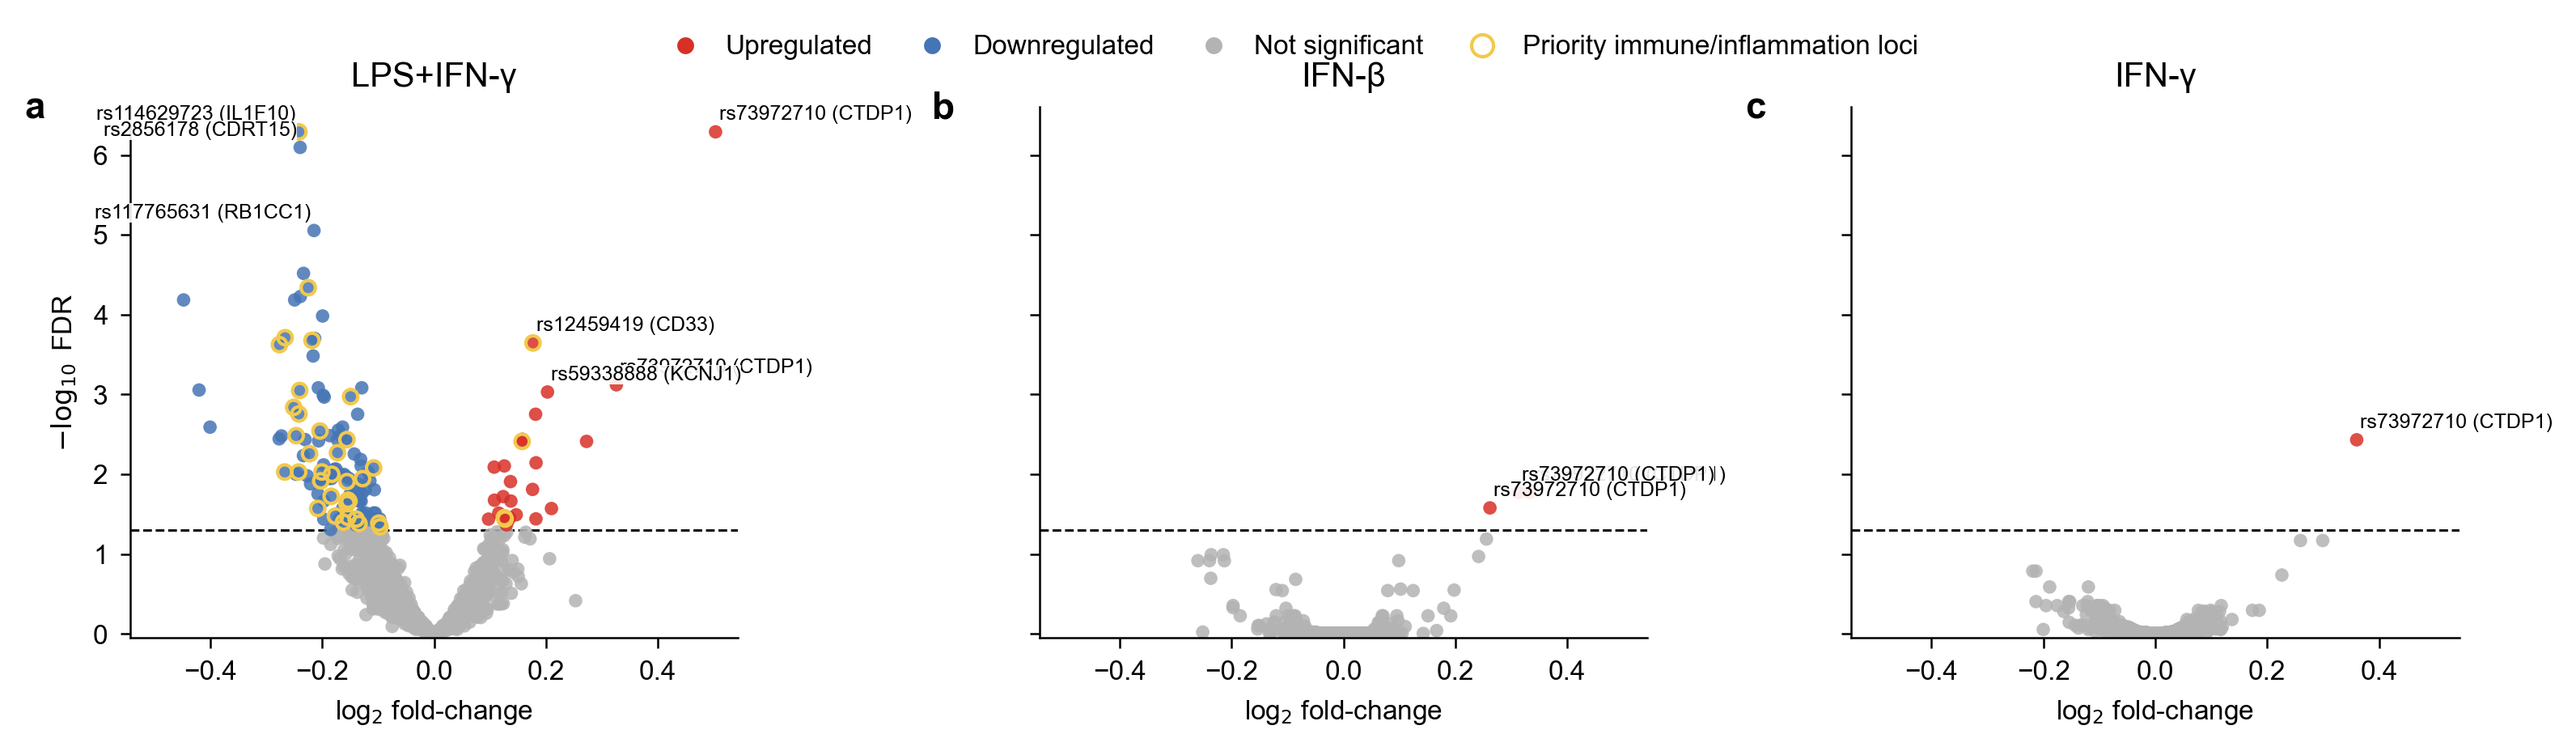

Saved to: E:\mpra3_lib_analysis\Fig_volcano_THP1_stimulation_yellowring_only.pdf
Saved to: E:\mpra3_lib_analysis\Fig_volcano_THP1_stimulation_yellowring_only.svg


In [45]:
#!/usr/bin/env python3
# ------------------------------------------------------------------
# Volcano plots (THP-1: LPS+IFNG, IFNB, IFNG)
# - shared y-axis
# - balanced labeling: top up + top down significant hits
# - highlight priority immune/inflammation loci with tight yellow outline only
# - Arial font
# - Illustrator-editable PDF/SVG
# ------------------------------------------------------------------

import re
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# --------------------------- CONFIG ---------------------------------
SIG_THR = 0.05
N_UP = 4
N_DOWN = 3
PANEL_W = 4.8
PANEL_H = 3.4
OUTFILE_PDF = "Fig_volcano_THP1_stimulation_yellowring_only.pdf"
OUTFILE_SVG = "Fig_volcano_THP1_stimulation_yellowring_only.svg"

BASE_POINT_SIZE = 16
RING_POINT_SIZE = 18   # slightly larger than the base point; tight outer ring
RING_LINEWIDTH = 1.0

COL = {
    "ns":   "#B3B3B3",   # non-significant
    "up":   "#D73027",   # significant up-regulated
    "down": "#4575B4",   # significant down-regulated
}
HIGHLIGHT_YELLOW = "#F2C94C"

# Priority immune/inflammation loci to circle
PRIORITY_GENES = {
    "HLA-DRB1",
    "IL1F10",
    "CD33",
    "MS4A6A",
    "TNFAIP2",
    "EPHA1",
    "S1PR1",
    "BCL3",
    "ATF3",
    "MAP3K7",
    "ALCAM",
    "PTK2B",
}

# -------------------- Illustrator-editable text ---------------------
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "Arial"

plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

# --------------------------- FUNCTIONS ------------------------------
def drop_rows_with_motifdisrupt(df: pd.DataFrame) -> pd.DataFrame:
    mask = df.iloc[:, 0].astype(str).str.contains("motifdisrupt", na=False)
    return df.loc[~mask].copy()

def load_diff_table(path: str) -> pd.DataFrame:
    return pd.read_csv(path, index_col=0)

def replace_indices_with_ref(df: pd.DataFrame, lut: pd.DataFrame) -> list[str]:
    idx_map = pd.Series(lut.iloc[:, 0].values, index=lut.iloc[:, 1]).to_dict()
    return [idx_map.get(i, i) if str(i).startswith("ref") else i for i in df.index]

def choose_balanced_hits(tmp: pd.DataFrame, sig_thr: float, n_up: int, n_down: int) -> pd.DataFrame:
    tmp_sig = tmp.loc[tmp["fdr"] <= sig_thr].copy()

    hits_up = (
        tmp_sig.loc[tmp_sig["logFC"] > 0]
        .sort_values(["fdr", "logFC"], ascending=[True, False])
        .head(n_up)
    )

    hits_down = (
        tmp_sig.loc[tmp_sig["logFC"] < 0]
        .sort_values(["fdr", "logFC"], ascending=[True, True])
        .head(n_down)
    )

    hits = pd.concat([hits_up, hits_down], axis=0).drop_duplicates()

    if not hits.empty:
        hits = hits.assign(abs_logFC=np.abs(hits["logFC"]))
        hits = hits.sort_values(
            ["-log10FDR", "abs_logFC"],
            ascending=[False, False]
        ).drop(columns="abs_logFC")

    return hits

def extract_gene(label: str) -> str | None:
    if pd.isna(label):
        return None
    m = re.search(r"\(([^()]+)\)", str(label))
    return m.group(1) if m else None

def simplify_label(label: str) -> str:
    """
    Convert:
    rs114629723(IL1F10) distal_enhancer
    -> rs114629723 (IL1F10)
    """
    if pd.isna(label):
        return ""
    label = str(label)
    m = re.match(r"^([^(]+)\(([^()]+)\)", label)
    if m:
        return f"{m.group(1).strip()} ({m.group(2).strip()})"
    return label

# --------------------------- DATA LOAD ------------------------------
df_index = pd.read_csv("indexing/ALT_REF_LookUpTable_filtered_amended_20231117.csv")
df_index = drop_rows_with_motifdisrupt(df_index)

annot_path = (
    "indexing/"
    "SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_"
    "Bellenguez_TSS_genomicML_20250324.csv"
)
df_annot = pd.read_csv(annot_path, index_col=0)

# Explicit plotting order: LPS first, then beta, then gamma
diff_files = [
    (
        "LPS+IFN-γ",
        "enhancer_activities_differential/20240626_comparative_THP1_LPSIFNGvsNaive_DifferentialEnhancer.csv",
    ),
    (
        "IFN-β",
        "enhancer_activities_differential/20240626_comparative_THP1_IFNBvsNaive_DifferentialEnhancer.csv",
    ),
    (
        "IFN-γ",
        "enhancer_activities_differential/20240626_comparative_THP1_IFNGvsNaive_DifferentialEnhancer.csv",
    ),
]

comparisons = [(title, load_diff_table(path)) for title, path in diff_files]

for _, df in comparisons:
    resolved_idx = replace_indices_with_ref(df, df_index)
    df["rsid_gene_label"] = df_annot.reindex(resolved_idx)["rsid_gene_label"].values
    df["gene"] = df["rsid_gene_label"].map(extract_gene)

# --------------------------- PREP -----------------------------------
max_abs = max(np.nanmax(np.abs(df["logFC"].values)) for _, df in comparisons)
max_y = 0

prepared = []
for title, df in comparisons:
    tmp = df.copy()
    tmp["-log10FDR"] = -np.log10(tmp["fdr"].clip(lower=1e-300))
    tmp["sig"] = "ns"
    tmp.loc[(tmp["fdr"] <= SIG_THR) & (tmp["logFC"] > 0), "sig"] = "up"
    tmp.loc[(tmp["fdr"] <= SIG_THR) & (tmp["logFC"] < 0), "sig"] = "down"

    tmp["is_priority"] = (tmp["fdr"] <= SIG_THR) & (tmp["gene"].isin(PRIORITY_GENES))

    max_y = max(max_y, tmp["-log10FDR"].max())
    prepared.append((title, tmp))

# --------------------------- PLOTTING -------------------------------
fig, axes = plt.subplots(
    ncols=3,
    sharey=True,
    figsize=(PANEL_W * 2.5*0.875, PANEL_H*0.83),
    constrained_layout=True
)

for ax, (title, tmp) in zip(axes, prepared):
    # Base layers
    for sig_class in ["ns", "down", "up"]:
        sub = tmp.loc[tmp["sig"] == sig_class]
        if sub.empty:
            continue
        ax.scatter(
            sub["logFC"],
            sub["-log10FDR"],
            s=BASE_POINT_SIZE,
            c=COL[sig_class],
            edgecolors="none",
            alpha=0.85,
            zorder=1
        )

    # Tight yellow outline only
    priority_sub = tmp.loc[tmp["is_priority"]].copy()
    if not priority_sub.empty:
        ax.scatter(
            priority_sub["logFC"],
            priority_sub["-log10FDR"],
            s=RING_POINT_SIZE,
            facecolors="none",
            edgecolors=HIGHLIGHT_YELLOW,
            linewidths=RING_LINEWIDTH,
            zorder=3
        )

    # FDR threshold
    ax.axhline(-np.log10(SIG_THR), ls="--", lw=0.7, color="black", zorder=0)

    # limits & style
    ax.set_xlim(-max_abs * 1.08, max_abs * 1.08)
    ax.set_ylim(-0.05, max_y * 1.05)
    ax.set_xlabel(r"log$_2$ fold-change", labelpad=4)
    ax.set_title(title, pad=6, fontsize=10)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # balanced label selection
    hits = choose_balanced_hits(tmp, SIG_THR, N_UP, N_DOWN)

    # annotate
    for _, row in hits.iterrows():
        raw_label = row["rsid_gene_label"] if pd.notna(row["rsid_gene_label"]) else ""
        label = simplify_label(raw_label)
        if label == "":
            continue

        x = row["logFC"]
        y = row["-log10FDR"]

        if x >= 0:
            dx = 0.012 * max_abs
            ha = "left"
        else:
            dx = -0.012 * max_abs
            ha = "right"

        dy = 0.10

        ax.text(
            x + dx,
            y + dy,
            label,
            fontsize=6,
            ha=ha,
            va="bottom",
            color="black",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.15, alpha=0.9),
            zorder=4
        )

# shared y-axis
axes[0].set_ylabel(r"$-\log_{10}$ FDR", labelpad=4)
for ax in axes[1:]:
    ax.set_ylabel("")

# panel letters
for label, ax in zip("abc", axes):
    ax.text(
        -0.14, 1.03, label,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        ha="right",
        va="top"
    )

# Legend outside panels
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COL["up"],
           markeredgecolor="none", markersize=5, label="Upregulated"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COL["down"],
           markeredgecolor="none", markersize=5, label="Downregulated"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=COL["ns"],
           markeredgecolor="none", markersize=5, label="Not significant"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
           markeredgecolor=HIGHLIGHT_YELLOW, markeredgewidth=RING_LINEWIDTH,
           markersize=6.5, label="Priority immune/inflammation loci"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.06),
    ncol=4,
    frameon=False,
    fontsize=8,
    handletextpad=0.5,
    columnspacing=1.2
)

fig.savefig(OUTFILE_PDF, bbox_inches="tight")
fig.savefig(OUTFILE_SVG, bbox_inches="tight")
plt.show()

print(f"Saved to: {Path(OUTFILE_PDF).resolve()}")
print(f"Saved to: {Path(OUTFILE_SVG).resolve()}")